In [24]:
# importing the depenencies 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 

warnings.filterwarnings("ignore")


In [3]:
!pip install xgboost

Looking in indexes: https://pypi.org/simple/
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [25]:
import sklearn.datasets 
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor 
from sklearn import metrics


In [26]:
from sklearn.datasets import fetch_openml
housing = fetch_openml(name="house_prices", as_frame=True)

In [27]:
type(housing)

sklearn.utils._bunch.Bunch

In [10]:
# this is the way of converting the bunch in to the dataframe the std way 

In [28]:
df = pd.DataFrame(housing.data , columns=housing.feature_names)
df['target'] = housing.target


df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,target
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


Id               False
MSSubClass       False
MSZoning         False
LotFrontage       True
LotArea          False
                 ...  
MoSold           False
YrSold           False
SaleType         False
SaleCondition    False
target           False
Length: 81, dtype: bool

In [30]:
df['LotFrontage'].fillna(df['LotFrontage'].mean() , inplace=True)

In [31]:
df.shape

(1460, 81)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [21]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,target
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [33]:
df.Alley.isna().sum()

np.int64(1369)

In [34]:
df['Alley'].fillna('No alley access' , inplace=True)

In [35]:
X = df.drop(['target'] , axis=1)
y = df['target']



In [36]:
from sklearn.model_selection import train_test_split

X_train , X_test  , y_train , y_test = train_test_split(X ,y , test_size=0.2 , random_state= 42 )


In [38]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore")
X_train_enc= encoder.fit_transform(X_train)
X_test_enc= encoder.transform(X_test)



In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train = scaler.fit_transform(X_train_enc)
X_test = scaler.transform(X_test_enc)

y_train = scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = scaler.transform(y_test.values.reshape(-1,1))

In [43]:
# loading the model
model = XGBRegressor()



In [44]:
# training the model with X_train
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [45]:
# accuracy for prediction on training data
training_data_prediction = model.predict(X_train)

In [46]:
# R squared error
score_1 = metrics.r2_score(y_train, training_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(y_train, training_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.9936381830115946
Mean Absolute Error :  0.06430884396689136


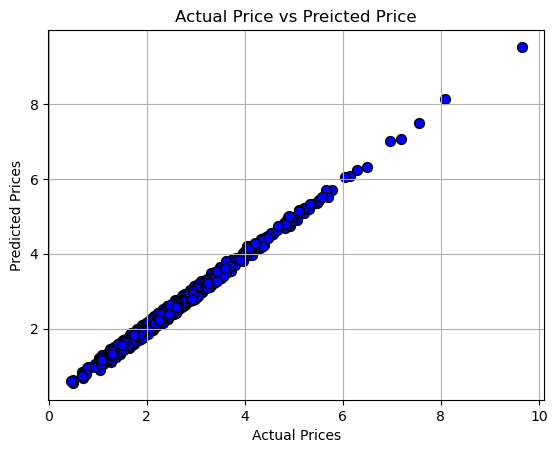

In [51]:
plt.scatter(y_train, training_data_prediction , color='blue' , s = 50 , edgecolor = 'k')
plt.xlabel("Actual Prices")
plt.grid()
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Preicted Price")

plt.show()

In [52]:
# accuracy for prediction on test data
test_data_prediction = model.predict(X_test)

In [54]:
# R squared error
score_1 = metrics.r2_score(y_test, test_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(y_test, test_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.8609638906173527
Mean Absolute Error :  0.273237210983941


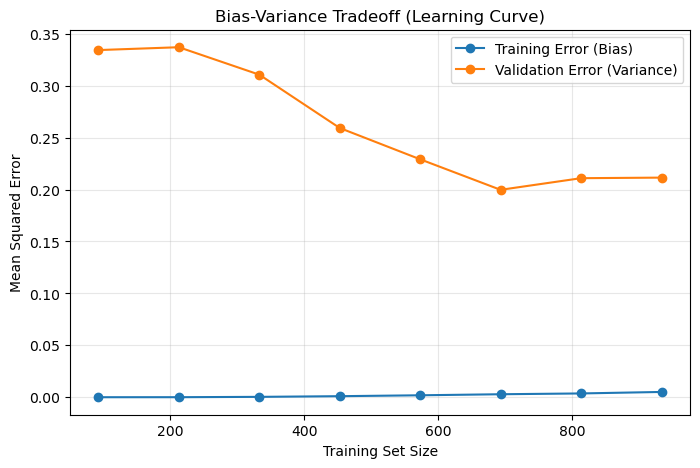

In [55]:
from sklearn.model_selection import learning_curve

# Use a fresh estimator with the same settings as the trained model
estimator = XGBRegressor(**model.get_params())

train_sizes, train_scores, val_scores = learning_curve(
    estimator=estimator,
    X=X_train,
    y=y_train.ravel(),
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Convert from negative MSE to MSE
train_mse = -train_scores.mean(axis=1)
val_mse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mse, marker="o", label="Training Error (Bias)")
plt.plot(train_sizes, val_mse, marker="o", label="Validation Error (Variance)")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Tradeoff (Learning Curve)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()